## 1. What this notebook computes

This notebook solves a small but complete Kohn-Sham problem from the first line to the
last, so that every step of density functional theory can be seen at work. Eight
identical fermions, four with the label "up" and four with the label "down", move on a
line in a harmonic trap and repel each other when they meet at the same point. The
notebook

- builds the one-particle Hamiltonian on a grid of 200 points and checks it against
  the exactly known levels of the harmonic trap;
- writes the Kohn-Sham potential of this model (external potential plus Hartree
  potential plus exchange potential) and solves the Kohn-Sham equations
  self-consistently in three ways: plain iteration, linear mixing, and Anderson
  mixing with exactly the settings that the Revision Kohn-Sham solver of the
  dirac16complex field uses (read from its parameter file);
- checks the particle number, computes the total energy in two different ways and
  checks that they agree, and tests with the energy whether the solution with equal
  up and down densities is stable (a converged loop alone cannot tell a minimum from
  a saddle, as two sites show);
- shows the variational principle at work: every other set of orbitals of a family
  gives a higher energy;
- compares the Kohn-Sham density with three simpler pictures: no interaction, the
  Hartree approximation (no exchange) and the Thomas-Fermi approximation (the local
  density approximation for the kinetic energy);
- switches the interaction on step by step and checks the Hellmann-Feynman theorem;
- computes the first excited state by the Delta-SCF method and checks Janak's
  theorem;
- draws ten teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 13a (A one-dimensional Kohn-Sham toy with self-consistency) is the file
`Revision/textbook/notebooks/13a_kohn_sham_1d_toy.ipynb` of the repository Dirac_claude.
It solves the Kohn-Sham equations of eight fermions with two labels in a one-dimensional
harmonic trap with a contact repulsion (Hartree plus the exact local exchange of this
interaction, no correlation) on a grid, by plain iteration, by linear mixing and by
Anderson mixing with the settings of the Revision Kohn-Sham solver; it checks the
particle number, the two energy formulas, that the mean-field potential is the functional
derivative of the interaction energy, the variational principle, the stability of the
equal-label solution and the Hellmann-Feynman theorem, compares the result with the
Hartree and the Thomas-Fermi approximations, computes the first excited state by
Delta-SCF and checks Janak's theorem, and draws ten teaching plots. It needs a computer
with Windows 11, macOS or Linux, an internet connection for the installation, the program
Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
nbconvert 7.16.6. The notebook itself imports numpy and matplotlib; the other packages
run Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 13a_kohn_sham_1d_toy.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 20 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 13a_kohn_sham_1d_toy.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
13a_kohn_sham_1d_toy.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/13a.captions.json`
- `Revision/textbook/figures/13a_1_trap_orbitals.png`
- `Revision/textbook/figures/13a_2_scf_convergence.png`
- `Revision/textbook/figures/13a_3_first_iterations.png`
- `Revision/textbook/figures/13a_4_ks_potentials.png`
- `Revision/textbook/figures/13a_5_density_orbitals.png`
- `Revision/textbook/figures/13a_6_label_separation.png`
- `Revision/textbook/figures/13a_7_variational_scan.png`
- `Revision/textbook/figures/13a_8_approximations.png`
- `Revision/textbook/figures/13a_9_coupling_scan.png`
- `Revision/textbook/figures/13a_10_delta_scf.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 13a_10_delta_scf.png exists
    ALL 36 CHECKS PASSED (notebook 13a)

and the notebook must show 10 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/13a_kohn_sham_1d_toy.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 13a_kohn_sham_1d_toy.ipynb
      python -m nbconvert --execute --inplace 13a_kohn_sham_1d_toy.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for `parameters.json`: the notebook reads the file
  `Revision/kohn_sham/results/parameters.json` of the repository; it must be opened
  inside the folder `Revision/textbook/notebooks` of a complete clone of the repository,
  not as a single downloaded file.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 13a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 13a (A one-dimensional Kohn-Sham toy with self-consistency) is the file
# Revision/textbook/notebooks/13a_kohn_sham_1d_toy.ipynb of the repository Dirac_claude.
# It solves the Kohn-Sham equations of eight fermions with two labels in a
# one-dimensional harmonic trap with a contact repulsion (Hartree plus the exact local
# exchange of this interaction, no correlation) on a grid, by plain iteration, by linear
# mixing and by Anderson mixing with the settings of the Revision Kohn-Sham solver; it
# checks the particle number, the two energy formulas, that the mean-field potential is
# the functional derivative of the interaction energy, the variational principle, the
# stability of the equal-label solution and the Hellmann-Feynman theorem, compares the
# result with the Hartree and the Thomas-Fermi approximations, computes the first excited
# state by Delta-SCF and checks Janak's theorem, and draws ten teaching plots. It needs a
# computer with Windows 11, macOS or Linux, an internet connection for the installation,
# the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
# with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
# matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
# and nbconvert 7.16.6. The notebook itself imports numpy and matplotlib; the other
# packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 13a_kohn_sham_1d_toy.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 20
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 13a_kohn_sham_1d_toy.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 13a_kohn_sham_1d_toy.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/13a.captions.json
# - Revision/textbook/figures/13a_1_trap_orbitals.png
# - Revision/textbook/figures/13a_2_scf_convergence.png
# - Revision/textbook/figures/13a_3_first_iterations.png
# - Revision/textbook/figures/13a_4_ks_potentials.png
# - Revision/textbook/figures/13a_5_density_orbitals.png
# - Revision/textbook/figures/13a_6_label_separation.png
# - Revision/textbook/figures/13a_7_variational_scan.png
# - Revision/textbook/figures/13a_8_approximations.png
# - Revision/textbook/figures/13a_9_coupling_scan.png
# - Revision/textbook/figures/13a_10_delta_scf.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 13a_10_delta_scf.png exists
#     ALL 36 CHECKS PASSED (notebook 13a)
#
# and the notebook must show 10 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/13a_kohn_sham_1d_toy.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 13a_kohn_sham_1d_toy.ipynb
#     python -m nbconvert --execute --inplace 13a_kohn_sham_1d_toy.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for parameters.json: the notebook reads the file
#   Revision/kohn_sham/results/parameters.json of the repository; it must be opened
#   inside the folder Revision/textbook/notebooks of a complete clone of the repository,
#   not as a single downloaded file.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "13a"  # this notebook: chapter 13, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 13a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Fermion**: a particle of a kind that obeys the Pauli principle: two identical
  fermions with the same label never occupy the same one-particle state.
- **Label**: an internal property of a particle that takes a few values; here two,
  "up" and "down" (like the spin of an electron). Particles with different labels
  can be told apart; particles with the same label cannot.
- **Orbital**: a one-particle wave function $\phi_a(x)$; its square $\phi_a(x)^2$ is
  the probability per unit length of finding the particle at $x$.
- **Density** $n(x)$: the expected number of particles per unit length at the point
  $x$. Its integral over the line is the particle number $N$.
- **Harmonic trap**: the external potential $v(x) = x^2/2$, a parabola; a particle in
  it has the levels $1/2, 3/2, 5/2, \dots$ (in the units below).
- **Contact interaction**: two particles feel a repulsion of strength $g_c$ only when
  they are at the same point.
- **Kohn-Sham equations**: one-particle Schroedinger equations in an effective
  potential $v_s(x)$ chosen so that their orbitals give the density of the
  interacting system.
- **Hartree potential**: the potential that one particle feels from the average
  density of all particles; **exchange potential**: the correction that comes from
  the Pauli principle (equal-label particles avoid each other).
- **Mean-field potential** $w(x)$: here the Hartree plus exchange potential, so that
  $v_s = v + w$.
- **Self-consistency**: the potential makes the orbitals, the orbitals make the
  density, the density makes the potential; a solution is self-consistent when the
  potential that comes out equals the potential that went in.
- **Iteration, residual**: one pass around the loop is an iteration; the residual is
  the largest difference between the potential that comes out and the one that went
  in.
- **Mixing**: feeding only part of the change back (linear mixing) or a combination
  of several earlier passes (Anderson mixing) to make the loop converge.
- **Grid, finite differences**: the line is replaced by equally spaced points; the
  second derivative is replaced by the difference formula
  $(f_{k+1} - 2 f_k + f_{k-1})/h^2$.
- **Eigenvalue, eigenvector**: for a matrix $A$, a number $\epsilon$ and a column
  $u$ with $A u = \epsilon u$; numpy's `eigh` finds all of them for a symmetric
  matrix.
- **Thomas-Fermi approximation**: the kinetic energy of each small piece of the
  line is taken from a uniform gas of the same density.
- **HOMO, LUMO**: the highest occupied and the lowest unoccupied orbital.
- **Delta-SCF**: an excited state computed as a second self-consistent solution in
  which one particle is moved by hand from the HOMO to the LUMO.
- **Units**: $\hbar = m = \omega = 1$, where $\omega$ is the angular frequency of the
  trap: energies are measured in units of $\hbar\omega$, lengths in units of
  $\sqrt{\hbar/(m\omega)}$, and $g_c$ in units of $\hbar\omega$ times that length.

## 4. The physical and mathematical situation

**The model.** $N = 8$ fermions on a line, four with label up and four with label
down, in the trap $v(x) = x^2/2$, with the contact repulsion
$w(x, x') = g_c\,\delta(x - x')$ of strength $g_c = 2$. The exact ground state would
be a wave function of eight variables; Kohn-Sham theory replaces it by orbitals of
one variable. (In this notebook the letter $x$ is the position on the line of the
toy model; it is not one of the author's spacetime coordinates $x_1, \dots, x_8$.)

**The Kohn-Sham equations of this model.** The orbitals obey

$$-\frac{1}{2}\,\frac{d^2\phi_a}{dx^2} + v_s(x)\,\phi_a(x) = \epsilon_a\,\phi_a(x),$$

and the four lowest orbitals are each occupied by one up and one down fermion, so

$$n(x) = 2 \sum_{a=0}^{3} \phi_a(x)^2, \qquad n_{up} = n_{down} = n/2 .$$

The energy is $E = T_s + \int v\,n\,dx + E_H + E_x$ with the kinetic energy of the
orbitals $T_s = 2\sum_{a=0}^{3} \int \phi_a\,(-\tfrac12\,d^2\phi_a/dx^2)\,dx$, the
Hartree energy $E_H = \tfrac{g_c}{2}\int n^2\,dx$ and the exchange energy
$E_x = -\tfrac{g_c}{2}\int (n_{up}^2 + n_{down}^2)\,dx = -\tfrac{g_c}{4}\int n^2\,dx$.
For a contact interaction the exchange energy of a Slater determinant is EXACTLY this
local formula (Notebook 13b checks it); the correlation energy is left out. So this
is an "exchange-only" Kohn-Sham scheme, which for a contact interaction is the same
as the Hartree-Fock approximation: an approximation to the true ground state.

**The Kohn-Sham potential.** The potential is the derivative of the energy with
respect to the density (the functional derivative): $\delta E_H/\delta n = g_c n$ and
$\delta E_x/\delta n_{up} = -g_c n_{up} = -g_c n/2$, so

$$v_s(x) = v(x) + g_c\,n(x) - \tfrac{g_c}{2}\,n(x) = v(x) + w(x),
\qquad w(x) = \tfrac{g_c}{2}\,n(x).$$

**Self-consistency.** Given a mean-field potential $w$, solve for the orbitals, form
$n$, and compute $w_{out} = g_c n/2$. A solution is a $w$ with $w_{out} = w$. The
residual of one pass is $r = \max_x |w_{out}(x) - w(x)|$; the loop stops when
$r \le 10^{-11}$, the stopping rule of the Revision Kohn-Sham solver.

**The energy, two ways.** Multiply the Kohn-Sham equation by $\phi_a$, integrate
and sum with the occupations 2: $2\sum_a \epsilon_a = T_s + \int v_s\,n\,dx
= T_s + \int v\,n\,dx + \tfrac{g_c}{2}\int n^2\,dx$. Since
$E_H + E_x = \tfrac{g_c}{4}\int n^2\,dx$, this gives the double-counting formula
$E = 2\sum_{a=0}^{3}\epsilon_a - (E_H + E_x)$, which the notebook compares with the
direct sum of the four energies.

**Status.** The model and its numbers are a teaching example (COMPUTED here). Its
only link to the Revision record is the method: the same Anderson mixing and the same
stopping rule as the Revision solver for the dirac16complex field.

## 5. The grid and the one-particle Hamiltonian

The line is cut to the interval $-6 < x < 6$ (the orbitals of the lowest levels are
negligibly small at its ends) and replaced by $M = 200$ interior points
$x_k = -6 + k h$, $k = 1, \dots, 200$, with spacing $h = 12/201$. An orbital is the
column of its values at these points, and the orbitals vanish at the two end points
$x = \pm 6$ (hard walls). The second derivative becomes the difference formula, so
the kinetic energy $-\tfrac12\,d^2/dx^2$ becomes the matrix `T` with $1/h^2$ on the
diagonal and $-1/(2h^2)$ just above and just below it.

In [2]:
import numpy as np  # arrays of numbers, matrices and linear algebra

L_HALF = 6.0  # the grid covers -6 < x < 6
M = 200  # the number of interior grid points
h = 2.0 * L_HALF / (M + 1)  # the grid spacing 12/201
x = -L_HALF + h * np.arange(1, M + 1)  # the grid points x_k, k = 1, ..., 200
v = 0.5 * x ** 2  # the harmonic trap v(x) = x^2/2 at every point

# The kinetic-energy matrix: 1/h^2 on the diagonal, -1/(2 h^2) beside it.
T = (np.diag(np.full(M, 1.0 / h ** 2))
     + np.diag(np.full(M - 1, -0.5 / h ** 2), 1)
     + np.diag(np.full(M - 1, -0.5 / h ** 2), -1))
say(f"grid: {M} points, spacing h = {h:.6f}")
check(np.allclose(T, T.T), "the kinetic-energy matrix is symmetric")

grid: 200 points, spacing h = 0.059701
PASS the kinetic-energy matrix is symmetric


The next cell defines the function `orbitals(w)`: it diagonalises the matrix
$T + \mathrm{diag}(v + w)$ (the Kohn-Sham Hamiltonian on the grid) and returns the
levels in increasing order and the orbitals as the columns of a matrix. numpy returns
eigenvectors of length 1 in the sense $\sum_k u_k^2 = 1$; dividing by $\sqrt h$ makes
$\sum_k \phi_k^2\,h = 1$, the grid form of $\int \phi^2\,dx = 1$. An eigenvector is
fixed only up to its sign; the function makes the first clearly nonzero value of each
orbital (counted from the left) positive, so that every run draws the same pictures.
With $w = 0$ the levels must be close to the exact levels $n + 1/2$ of the trap; the
difference formula makes errors of order $h^2$, so the check allows $0.02$.

In [3]:
def orbitals(w):
    """Levels (increasing) and orbitals (columns, int phi^2 dx = 1) of T + v + w."""
    levels, vectors = np.linalg.eigh(T + np.diag(v + w))
    phi = vectors / np.sqrt(h)  # normalise to sum phi^2 h = 1
    for a in range(M):  # fix the sign of every orbital
        first = np.argmax(np.abs(phi[:, a]) > 1e-3 * np.abs(phi[:, a]).max())
        phi[:, a] *= np.sign(phi[first, a])
    return levels, phi


free_levels, free_phi = orbitals(np.zeros(M))  # no interaction: w = 0
exact_levels = np.arange(8) + 0.5  # 1/2, 3/2, ..., 15/2
for a in range(8):
    say(f"level {a}: grid {free_levels[a]:.6f}   exact {exact_levels[a]:.1f}")
check(np.max(np.abs(free_levels[:8] - exact_levels)) < 0.02,
      "the grid reproduces the levels n + 1/2 of the trap within 0.02")
overlaps = free_phi[:, :8].T @ free_phi[:, :8] * h  # sum_k phi_a phi_b h
check(np.allclose(overlaps, np.eye(8), atol=1e-12),
      "the orbitals are orthonormal on the grid")

level 0: grid 0.499889   exact 0.5
level 1: grid 1.499443   exact 1.5
level 2: grid 2.498551   exact 2.5
level 3: grid 3.497213   exact 3.5
level 4: grid 4.495429   exact 4.5
level 5: grid 5.493197   exact 5.5
level 6: grid 6.490519   exact 6.5
level 7: grid 7.487394   exact 7.5
PASS the grid reproduces the levels n + 1/2 of the trap within 0.02
PASS the orbitals are orthonormal on the grid


The next cell draws the trap, the six lowest levels as horizontal lines and each
orbital drawn around its own level (the orbital times 0.6, shifted up by its level).
The four lowest levels are the ones that the eight fermions occupy (two per level,
one up and one down).

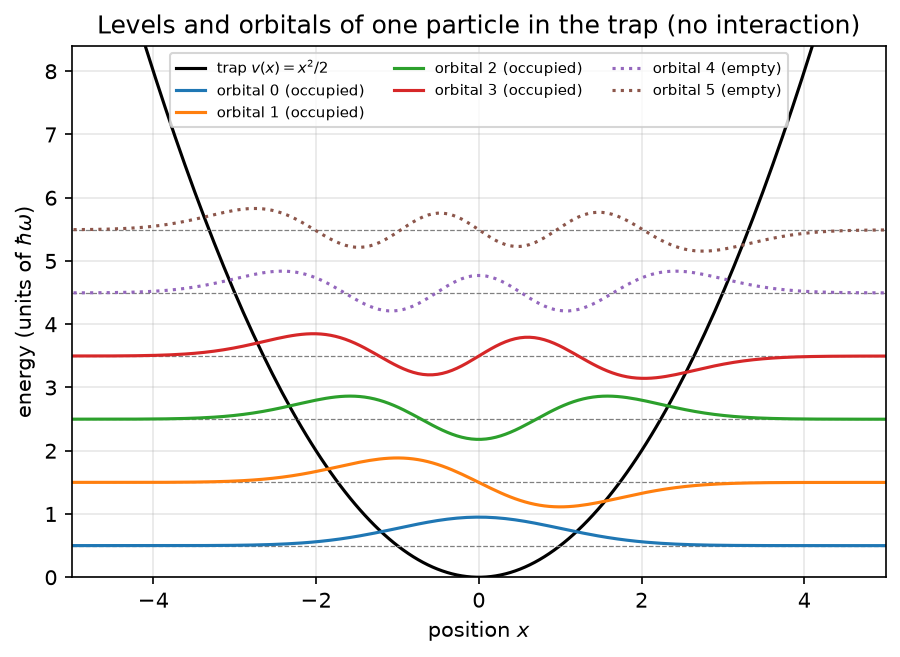

Figure 13a.1 saved as Revision/textbook/figures/13a_1_trap_orbitals.png


In [4]:
fig, ax = plt.subplots(figsize=(7.0, 4.6))
ax.plot(x, v, color="black", label="trap $v(x) = x^2/2$")
for a in range(6):
    style = "-" if a < 4 else ":"  # occupied: solid; empty: dotted
    ax.axhline(free_levels[a], color="gray", lw=0.6, ls="--")
    ax.plot(x, free_levels[a] + 0.6 * free_phi[:, a], style,
            label=f"orbital {a}" + (" (occupied)" if a < 4 else " (empty)"))
ax.set_xlim(-5.0, 5.0)
ax.set_ylim(0.0, 8.4)  # room above the orbitals for the legend
ax.set_xlabel("position $x$")
ax.set_ylabel("energy (units of $\\hbar\\omega$)")
ax.set_title("Levels and orbitals of one particle in the trap (no interaction)")
ax.legend(fontsize=7, loc="upper center", ncol=3)
save_figure(fig, "trap_orbitals",
            "The harmonic trap $v(x) = x^2/2$ (black parabola), its six lowest "
            "levels $1/2, 3/2, \\dots, 11/2$ (dashed lines) and the orbital of each "
            "level drawn around it (0.6 times the orbital, shifted up by its level), "
            "computed on the grid without interaction; horizontal axis the position "
            "$x$, vertical axis the energy in units of $\\hbar\\omega$. Orbital $a$ "
            "has $a$ zeros; the four lowest (solid) hold the eight fermions, two per "
            "level, the others (dotted) are empty.")

## 6. The Kohn-Sham map: from a mean-field potential to a new one

The next cell defines the parameters of the model and three functions:
`density(phi)` makes $n = 2\sum_{a=0}^{3}\phi_a^2$ from the orbitals,
`ks_map(w)` makes one pass of the loop ($w \to$ orbitals $\to n \to w_{out}$), and
`integral(f)` approximates $\int f\,dx$ by the sum $\sum_k f_k\,h$ (the function
vanishes at the walls, so this simple sum is accurate).

In [5]:
G_C = 2.0  # the strength g_c of the contact repulsion
N_PER_LABEL = 4  # four fermions with label up and four with label down
N_TOTAL = 2 * N_PER_LABEL


def integral(f):
    """The integral of f over the line, as the sum of f_k h."""
    return float(np.sum(f) * h)


def density(phi):
    """n(x) = 2 (phi_0^2 + phi_1^2 + phi_2^2 + phi_3^2): two fermions per orbital."""
    return 2.0 * np.sum(phi[:, :N_PER_LABEL] ** 2, axis=1)


def ks_map(w):
    """One pass of the loop: the mean-field potential g_c n / 2 made from w."""
    levels, phi = orbitals(w)
    return 0.5 * G_C * density(phi)


w_first = ks_map(np.zeros(M))  # one pass, starting from no interaction
report("largest value of the first mean-field potential", f"{w_first.max():.6f}")
check(abs(integral(2.0 * w_first / G_C) - N_TOTAL) < 1e-10,
      "the density of one pass holds exactly 8 particles")

RESULT largest value of the first mean-field potential = 1.887848
PASS the density of one pass holds exactly 8 particles


## 7. Plain iteration and linear mixing

**Linear mixing** with the mixing parameter $\beta$ replaces $w$ by
$w + \beta\,(w_{out} - w)$; $\beta = 1$ is **plain iteration**
($w \leftarrow w_{out}$). The function `linear_mixing(beta)` starts from $w = 0$,
records the residual of every pass and stops at a residual of at most $10^{-11}$, or
after 150 passes. It returns the last $w$, the list of residuals, and the densities
of the first passes (for a plot below).

In [6]:
def linear_mixing(beta, tolerance=1e-11, max_passes=150):
    """Linear mixing w <- w + beta (w_out - w), starting from w = 0."""
    w = np.zeros(M)
    residuals, first_densities = [], []
    for _ in range(max_passes):
        w_out = ks_map(w)
        residuals.append(np.max(np.abs(w_out - w)))  # the residual r
        if len(first_densities) < 5:
            first_densities.append(2.0 * w_out / G_C)  # n = 2 w_out / g_c
        if residuals[-1] <= tolerance:
            break
        w = w + beta * (w_out - w)
    return w, residuals, first_densities


runs = {}
for beta in (1.0, 0.7, 0.3):
    runs[beta] = linear_mixing(beta)
    say(f"beta = {beta}: {len(runs[beta][1])} passes, last residual "
        f"{runs[beta][1][-1]:.1e}")
check(all(run[1][-1] <= 1e-11 for run in runs.values()),
      "plain iteration and linear mixing with beta = 0.7 and 0.3 all converge")

beta = 1.0: 40 passes, last residual 9.5e-12
beta = 0.7: 23 passes, last residual 3.8e-12
beta = 0.3: 73 passes, last residual 8.7e-12
PASS plain iteration and linear mixing with beta = 0.7 and 0.3 all converge


## 8. Anderson mixing with the settings of the Revision solver

**Anderson mixing** remembers the last few inputs $w^{(i)}$ and their residual
vectors $R^{(i)} = w_{out}^{(i)} - w^{(i)}$, finds numbers $c_i$ with
$\sum_i c_i = 1$ that make the combined residual $\sum_i c_i R^{(i)}$ as small as
possible (a least-squares problem), and takes as the next input
$\sum_i c_i\,(w^{(i)} + \beta R^{(i)})$. The Revision Kohn-Sham solver of the
dirac16complex field uses this method; the next cell reads its settings (how many
earlier passes it remembers, its $\beta$ and its tolerance) from the Revision
parameter file and checks them.

What the Revision solver mixes is the list of its potentials at every grid point of
the hidden direction (the mass shift $M_{eff} - m$, the potential $v_v$, and a third
potential used only by one variant), and its residual is, as here, the largest
difference between the potentials that come out and those that went in. It solves
the same least-squares problem in an equivalent form (with a Lagrange multiplier
for the condition that the $c_i$ add up to 1) and adds two safeguards that this
small toy does not need: a tiny number ($10^{-12}$ times the largest diagonal
entry) on the diagonal of its equations, which keeps them solvable, and a restart
of the remembered passes whenever the residual grows to more than ten times the
best one so far.

In [7]:
parameters = json.loads(repository_file(
    "Revision/kohn_sham/results/parameters.json").read_text(encoding="utf-8"))
numerics = parameters["numerics"]  # the numerical settings of the Revision solver
DEPTH = int(numerics["andersonDepth"])  # how many earlier passes are remembered
BETA_ANDERSON = float(numerics["andersonBeta"])  # the mixing parameter
TOLERANCE = float(numerics["scfTolerance"])  # the stopping rule
say(f"Revision solver settings: depth {DEPTH}, beta {BETA_ANDERSON}, "
    f"tolerance {TOLERANCE:.0e}")
check(DEPTH == 6 and BETA_ANDERSON == 0.4 and abs(TOLERANCE - 1e-11) < 1e-24,
      "the Revision solver mixes with depth 6, beta 0.4 and stops at 1e-11 "
      "(Revision/kohn_sham/results/parameters.json, numerics)")

Revision solver settings: depth 6, beta 0.4, tolerance 1e-11
PASS the Revision solver mixes with depth 6, beta 0.4 and stops at 1e-11
    (Revision/kohn_sham/results/parameters.json, numerics)


The next cell defines the function `anderson(step, w0)`. It works for any map
`step` (here `ks_map`; below also maps of two potentials at once). With one
remembered pass it is linear mixing; with more, it solves the least-squares problem
with numpy's `lstsq`: writing $c_i = \theta_i$ for the older passes and
$c_{last} = 1 - \sum_i \theta_i$, the combined residual is
$R^{(last)} + \sum_i \theta_i (R^{(i)} - R^{(last)})$, which is smallest for the
least-squares solution $\theta$ of $\sum_i \theta_i (R^{(i)} - R^{(last)}) \approx
-R^{(last)}$.

In [8]:
def anderson(step, w0, beta=BETA_ANDERSON, depth=DEPTH, tolerance=TOLERANCE,
             max_passes=400):
    """Anderson mixing for the fixed point step(w) = w, starting from w0."""
    w = np.array(w0, dtype=float)
    inputs, residual_vectors, residuals = [], [], []
    for _ in range(max_passes):
        residual = step(w) - w  # R = w_out - w
        residuals.append(np.max(np.abs(residual)))
        if residuals[-1] <= tolerance:
            return w, residuals
        inputs = (inputs + [w.copy()])[-depth:]  # keep the last `depth` passes
        residual_vectors = (residual_vectors + [residual])[-depth:]
        if len(inputs) == 1:
            w = w + beta * residual  # the first pass: linear mixing
            continue
        last_r = residual_vectors[-1]
        differences = np.array([r - last_r for r in residual_vectors[:-1]]).T
        theta = np.linalg.lstsq(differences, -last_r, rcond=None)[0]
        c = np.append(theta, 1.0 - theta.sum())  # the c_i; they add up to 1
        w = sum(ci * (wi + beta * ri)
                for ci, wi, ri in zip(c, inputs, residual_vectors))
    raise RuntimeError("Anderson mixing did not converge")


w_scf, anderson_residuals = anderson(ks_map, np.zeros(M))
say(f"Anderson mixing: {len(anderson_residuals)} passes, last residual "
    f"{anderson_residuals[-1]:.1e}")
differences = [np.max(np.abs(runs[beta][0] - w_scf)) for beta in runs]
check(max(differences) < 1e-9,
      "all four routes reach the same self-consistent potential (within 1e-9)")
check(len(anderson_residuals) < len(runs[1.0][1]),
      "Anderson mixing needs fewer passes than plain iteration")

Anderson mixing: 19 passes, last residual 1.8e-12
PASS all four routes reach the same self-consistent potential (within 1e-9)
PASS Anderson mixing needs fewer passes than plain iteration


The next cell draws the residual of every pass for the four routes, on a logarithmic
vertical axis (each grid line is a factor 10). A straight falling line means that
every pass shrinks the residual by the same factor.

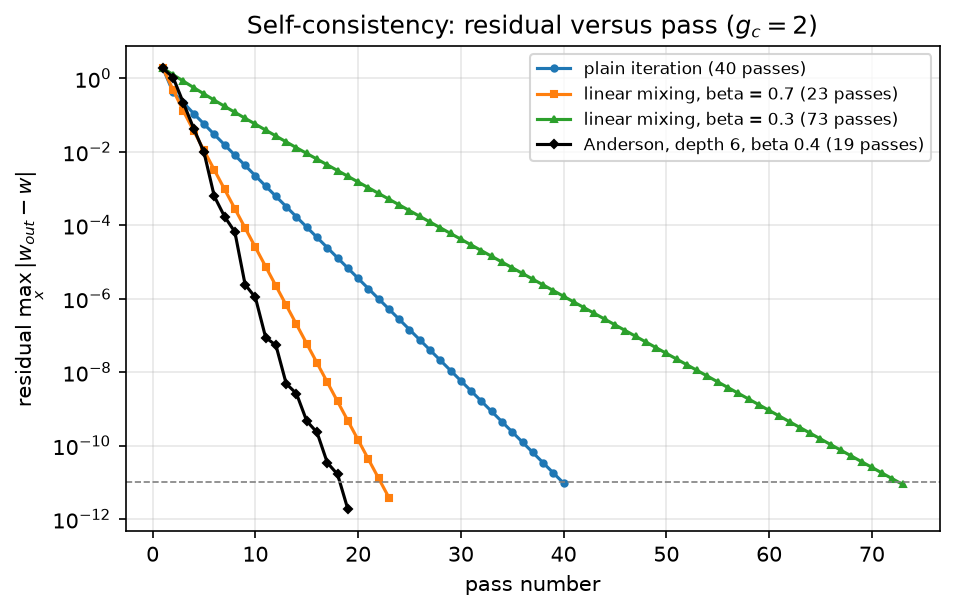

Figure 13a.2 saved as Revision/textbook/figures/13a_2_scf_convergence.png


In [9]:
fig, ax = plt.subplots()
for beta, style in ((1.0, "o-"), (0.7, "s-"), (0.3, "^-")):
    name = "plain iteration" if beta == 1.0 else f"linear mixing, beta = {beta}"
    ax.semilogy(range(1, len(runs[beta][1]) + 1), runs[beta][1], style, ms=3,
                label=f"{name} ({len(runs[beta][1])} passes)")
ax.semilogy(range(1, len(anderson_residuals) + 1), anderson_residuals, "D-",
            ms=3, color="black",
            label=f"Anderson, depth 6, beta 0.4 ({len(anderson_residuals)} passes)")
ax.axhline(TOLERANCE, color="gray", ls="--", lw=0.8)
ax.set_xlabel("pass number")
ax.set_ylabel("residual $\\max_x |w_{out} - w|$")
ax.set_title("Self-consistency: residual versus pass ($g_c = 2$)")
ax.legend(fontsize=8)
save_figure(fig, "scf_convergence",
            "The residual $\\max_x |w_{out}(x) - w(x)|$ of every pass of the "
            "self-consistency loop, logarithmic vertical axis (pure number in "
            "units of $\\hbar\\omega$), horizontal axis the pass number, for plain "
            "iteration, linear mixing with $\\beta = 0.7$ and $0.3$, and Anderson "
            "mixing with the settings of the Revision solver; the dashed line is "
            "the stopping rule $10^{-11}$. Every route reaches the same solution; "
            "the speed depends on $\\beta$, and Anderson mixing is fastest without "
            "any tuning.")

The next cell shows WHY plain iteration is slow here. It draws the densities that
the first four passes of plain iteration produce, together with the final density.
The first pass starts without interaction, so its density is too narrow; the
repulsion it causes then pushes the next density too far out; and so on: the
density "breathes" in and out around the solution while the swings shrink.

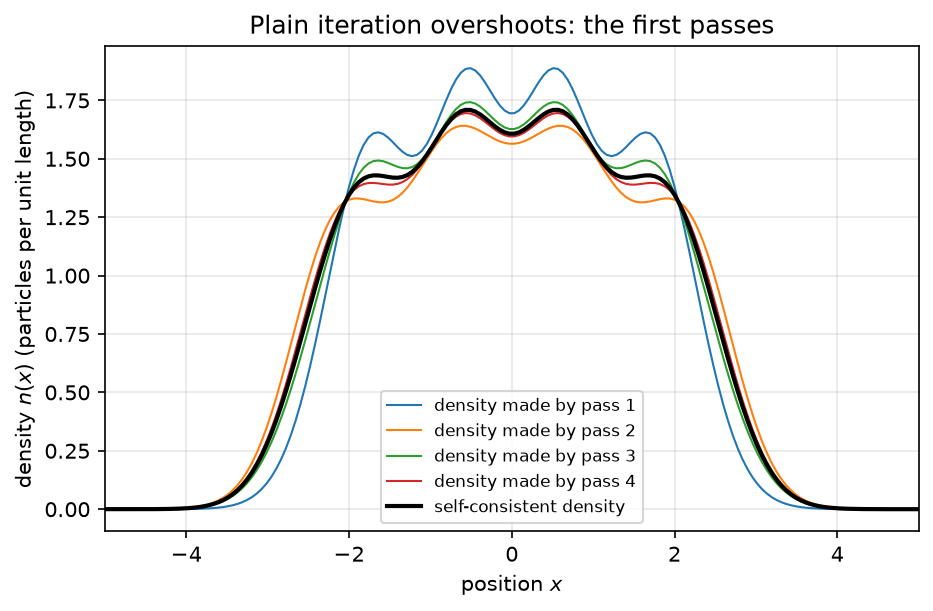

Figure 13a.3 saved as Revision/textbook/figures/13a_3_first_iterations.png
PASS the first pass is too narrow and the second too wide (overshooting)


In [10]:
n_scf = 2.0 * w_scf / G_C  # the self-consistent density n = 2 w / g_c
fig, ax = plt.subplots()
for number, n_pass in enumerate(runs[1.0][2][:4], 1):
    ax.plot(x, n_pass, lw=1.0, label=f"density made by pass {number}")
ax.plot(x, n_scf, color="black", lw=2.0, label="self-consistent density")
ax.set_xlim(-5.0, 5.0)
ax.set_xlabel("position $x$")
ax.set_ylabel("density $n(x)$ (particles per unit length)")
ax.set_title("Plain iteration overshoots: the first passes")
ax.legend(fontsize=8)
save_figure(fig, "first_iterations",
            "The densities made by the first four passes of plain iteration "
            "(thin lines) and the self-consistent density (thick black line); "
            "horizontal axis the position $x$, vertical axis the density in "
            "particles per unit length. Pass 1 starts without repulsion and is too "
            "narrow, pass 2 is too wide, pass 3 too narrow again: the density "
            "swings around the solution, and the swings shrink only slowly.")
check(runs[1.0][2][0].max() > n_scf.max() > runs[1.0][2][1].max(),
      "the first pass is too narrow and the second too wide (overshooting)")

## 9. The converged Kohn-Sham state

The next cell computes the orbitals of the self-consistent potential, their levels
and the density, and checks the particle number. The highest occupied level (HOMO,
level 3) and the lowest empty one (LUMO, level 4) are printed with the others.

In [11]:
ks_levels, ks_phi = orbitals(w_scf)
n_ks = density(ks_phi)
for a in range(6):
    status = "occupied by 2" if a < N_PER_LABEL else "empty"
    say(f"Kohn-Sham level {a}: {ks_levels[a]:.6f} ({status})")
report("Kohn-Sham HOMO level", f"{ks_levels[3]:.6f}")
report("Kohn-Sham LUMO level", f"{ks_levels[4]:.6f}")
check(abs(integral(n_ks) - N_TOTAL) < 1e-10, "the density integrates to N = 8")
check(np.max(np.abs(n_ks - n_scf)) < 1e-10,
      "the density of the final orbitals reproduces the input density")

Kohn-Sham level 0: 2.119598 (occupied by 2)
Kohn-Sham level 1: 3.006214 (occupied by 2)
Kohn-Sham level 2: 3.877952 (occupied by 2)
Kohn-Sham level 3: 4.723945 (occupied by 2)
Kohn-Sham level 4: 5.496606 (empty)
Kohn-Sham level 5: 6.370592 (empty)
RESULT Kohn-Sham HOMO level = 4.723945
RESULT Kohn-Sham LUMO level = 5.496606
PASS the density integrates to N = 8
PASS the density of the final orbitals reproduces the input density


The next cell draws the potentials of the converged state: the trap $v$, the Hartree
potential $v_H = g_c n$, the exchange potential $v_x = -g_c n/2$ and their sum
$v_s = v + v_H + v_x$, with the four occupied Kohn-Sham levels.

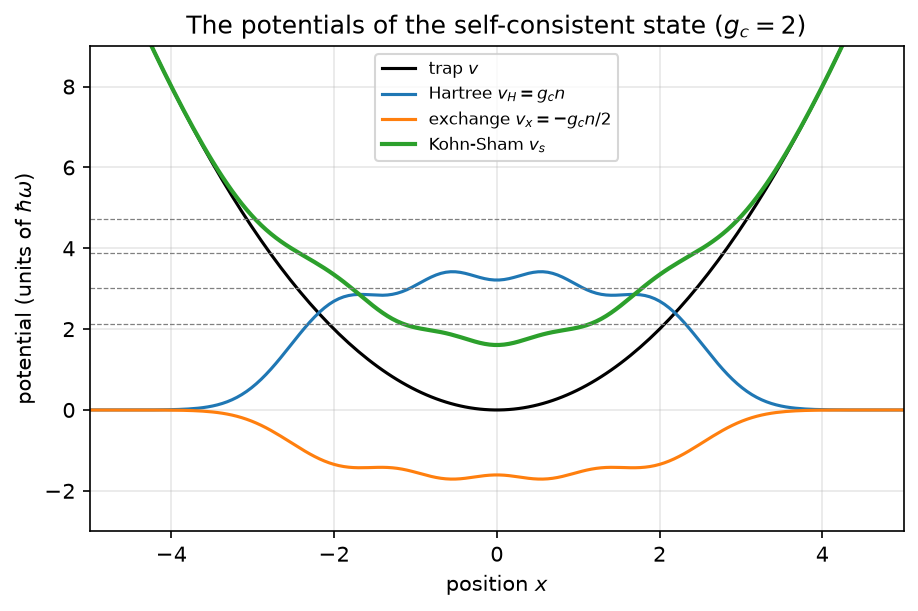

Figure 13a.4 saved as Revision/textbook/figures/13a_4_ks_potentials.png
PASS v + v_H + v_x equals the self-consistent v + w


In [12]:
v_hartree = G_C * n_ks  # v_H = g_c n
v_exchange = -0.5 * G_C * n_ks  # v_x = -g_c n_up = -g_c n / 2
fig, ax = plt.subplots()
ax.plot(x, v, color="black", label="trap $v$")
ax.plot(x, v_hartree, label="Hartree $v_H = g_c n$")
ax.plot(x, v_exchange, label="exchange $v_x = -g_c n/2$")
ax.plot(x, v + v_hartree + v_exchange, lw=2.0, label="Kohn-Sham $v_s$")
for a in range(N_PER_LABEL):
    ax.axhline(ks_levels[a], color="gray", ls="--", lw=0.6)
ax.set_xlim(-5.0, 5.0)
ax.set_ylim(-3.0, 9.0)
ax.set_xlabel("position $x$")
ax.set_ylabel("potential (units of $\\hbar\\omega$)")
ax.set_title("The potentials of the self-consistent state ($g_c = 2$)")
ax.legend(fontsize=8)
save_figure(fig, "ks_potentials",
            "The potentials of the self-consistent Kohn-Sham state: the trap $v$, "
            "the Hartree potential $v_H = g_c n$, the exchange potential "
            "$v_x = -g_c n/2$ and their sum $v_s$ (thick line), with the four "
            "occupied levels (dashed); horizontal axis the position $x$, vertical "
            "axis the potential in units of $\\hbar\\omega$. The repulsion flattens "
            "the bottom of the trap; exchange removes exactly half of the Hartree "
            "push, because a fermion feels no contact force from fermions with "
            "its own label.")
check(np.allclose(v + v_hartree + v_exchange, v + w_scf, atol=1e-10),
      "v + v_H + v_x equals the self-consistent v + w")

The next cell draws the density as a stack: each occupied orbital contributes
$2\phi_a(x)^2$ (one up and one down fermion), and the four layers add up to $n(x)$.
The four bumps of the density come from the four occupied orbitals (shell
structure).

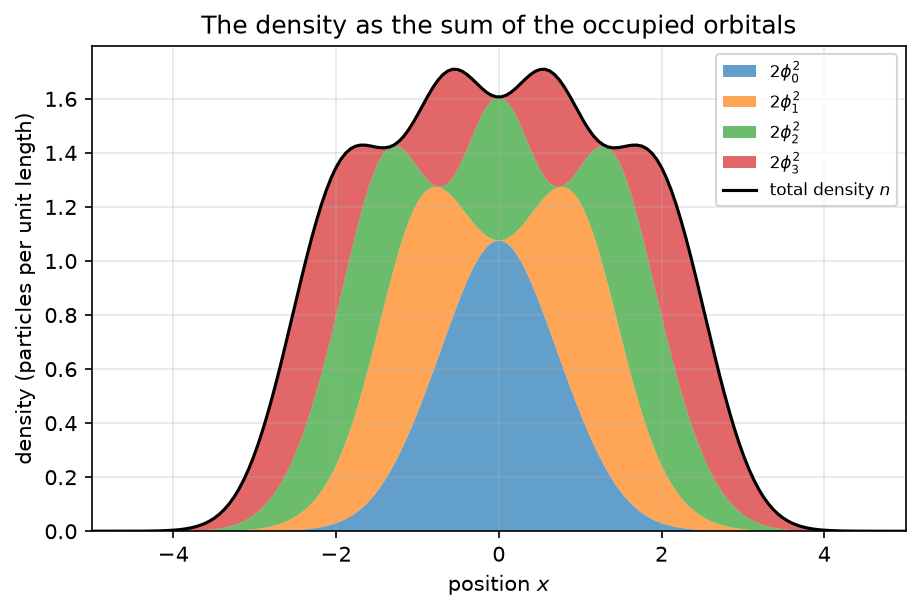

Figure 13a.5 saved as Revision/textbook/figures/13a_5_density_orbitals.png


In [13]:
fig, ax = plt.subplots()
layers = [2.0 * ks_phi[:, a] ** 2 for a in range(N_PER_LABEL)]
ax.stackplot(x, layers, labels=[f"$2\\phi_{a}^2$" for a in range(N_PER_LABEL)],
             alpha=0.7)
ax.plot(x, n_ks, color="black", lw=1.5, label="total density $n$")
ax.set_xlim(-5.0, 5.0)
ax.set_xlabel("position $x$")
ax.set_ylabel("density (particles per unit length)")
ax.set_title("The density as the sum of the occupied orbitals")
ax.legend(fontsize=8)
save_figure(fig, "density_orbitals",
            "The self-consistent density $n(x)$ (black line) as a stack of the "
            "contributions $2\\phi_a(x)^2$ of the four occupied Kohn-Sham orbitals "
            "(colored layers, orbital 0 at the bottom); horizontal axis the "
            "position $x$, vertical axis particles per unit length. The area under "
            "each layer is 2 and under the black line 8; the four bumps are the "
            "shell structure of the four occupied orbitals.")

## 10. The energy, two ways, and the stability of the solution

The next cell computes the four energies $T_s$, $\int v n\,dx$, $E_H$, $E_x$, their
sum $E$, and the double-counting formula $E = 2\sum_a \epsilon_a - (E_H + E_x)$ of
section 4. Both must agree to rounding. It also checks $E_x = -E_H/2$, which holds
exactly when the two labels are equally occupied (the rule $E_x = -E_H/g$ with
$g = 2$ labels).

In [14]:
def kinetic(phi, occupations):
    """T_s = sum_a f_a int phi_a (-1/2 phi_a'') dx with the occupations f_a."""
    return sum(f * float(phi[:, a] @ (T @ phi[:, a])) * h
               for a, f in enumerate(occupations))


T_s = kinetic(ks_phi, [2.0] * N_PER_LABEL)
E_ext = integral(v * n_ks)
E_H = 0.5 * G_C * integral(n_ks ** 2)
E_x = -0.25 * G_C * integral(n_ks ** 2)
E_total = T_s + E_ext + E_H + E_x
E_double = 2.0 * ks_levels[:N_PER_LABEL].sum() - (E_H + E_x)
for label, value in (("kinetic T_s", T_s), ("external int v n dx", E_ext),
                     ("Hartree E_H", E_H), ("exchange E_x", E_x)):
    say(f"{label:22} = {value:.6f}")
report("total energy E (direct sum)", f"{E_total:.6f}")
report("total energy E (double counting)", f"{E_double:.6f}")
check(abs(E_total - E_double) < 1e-9, "the two energy formulas agree")
check(abs(E_x + 0.5 * E_H) < 1e-12, "E_x = -E_H/2 for two equally occupied labels")

kinetic T_s            = 6.726297
external int v n dx    = 9.521279
Hartree E_H            = 11.207843
exchange E_x           = -5.603922
RESULT total energy E (direct sum) = 21.851498
RESULT total energy E (double counting) = 21.851498
PASS the two energy formulas agree
PASS E_x = -E_H/2 for two equally occupied labels


Section 4 obtained the mean-field potential $w = g_c n/2$ as the **functional
derivative** of the interaction energy $E_H + E_x = \tfrac{g_c}{4}\int n^2\,dx$
with respect to the density. On the grid this has a concrete meaning that the next
cell tests: change the density by a small amount $\epsilon\,\eta(x)$, where $\eta$
is any fixed function (here the off-centre bump $\eta(x) = e^{-(x - 1)^2}$); then
the interaction energy changes, to first order in $\epsilon$, by
$\epsilon\int w\,\eta\,dx$. The cell compares the difference quotient
$(E_{Hx}[n + \epsilon\eta] - E_{Hx}[n - \epsilon\eta])/(2\epsilon)$ with
$\epsilon = 10^{-4}$ and the integral $\int w\,\eta\,dx$. (Because $E_H + E_x$ is
a square of $n$, the difference quotient is exact here up to rounding.)

In [15]:
def interaction_energy(n):
    """E_H + E_x = (g_c/4) int n^2 dx for two equally occupied labels."""
    return 0.25 * G_C * integral(n ** 2)


eta = np.exp(-(x - 1.0) ** 2)  # a fixed change of shape, off the centre of the trap
epsilon = 1e-4  # the size of the change
quotient = (interaction_energy(n_ks + epsilon * eta)
            - interaction_energy(n_ks - epsilon * eta)) / (2.0 * epsilon)
w_ks = 0.5 * G_C * n_ks  # the mean-field potential w = g_c n / 2
report("difference quotient of E_H + E_x along eta", f"{quotient:.10f}")
report("integral of w eta dx", f"{integral(w_ks * eta):.10f}")
check(abs(quotient - integral(w_ks * eta)) < 1e-9,
      "w = g_c n/2 is the functional derivative of E_H + E_x")

RESULT difference quotient of E_H + E_x along eta = 2.6845567944
RESULT integral of w eta dx = 2.6845567944
PASS w = g_c n/2 is the functional derivative of E_H + E_x


So far the up and down densities were forced to be equal. Is that solution stable,
or would the fermions lower their energy by separating the labels? The next cell
lets the two labels have their own potentials: a fermion with label up feels the
Hartree potential of everybody minus the exchange with its own label,
$v_{up} = v + g_c n - g_c n_{up} = v + g_c n_{down}$, and the same with up and down
exchanged. It starts from a strongly separated guess (up pushed to the left, down to
the right) and runs Anderson mixing on both potentials together. At $g_c = 2$ the
loop returns to equal densities and to the same energy. This return does NOT yet
show that the equal-label solution is stable: the two cells after it show why, and
make the test that does.

In [16]:
def label_densities(w_pair, up_occupations, down_occupations):
    """The densities n_up, n_down and the levels for the pair of potentials."""
    up_levels, up_phi = orbitals(w_pair[:M])  # w_up: the first M numbers
    down_levels, down_phi = orbitals(w_pair[M:])  # w_down: the last M numbers
    n_up = (up_phi[:, :len(up_occupations)] ** 2) @ np.array(up_occupations)
    n_down = (down_phi[:, :len(down_occupations)] ** 2) @ np.array(down_occupations)
    return n_up, n_down, up_levels, up_phi, down_levels, down_phi


def labels_map(w_pair, up_occupations, down_occupations):
    """One pass for two labels: w_up = g_c n_down and w_down = g_c n_up."""
    n_up, n_down = label_densities(w_pair, up_occupations, down_occupations)[:2]
    return np.concatenate([G_C * n_down, G_C * n_up])


def labels_energy(w_pair, up_occupations, down_occupations):
    """E = T_s + int v n + g_c int n_up n_down (E_H + E_x for two labels)."""
    n_up, n_down, _, up_phi, _, down_phi = label_densities(
        w_pair, up_occupations, down_occupations)
    return (kinetic(up_phi, up_occupations) + kinetic(down_phi, down_occupations)
            + integral(v * (n_up + n_down)) + G_C * integral(n_up * n_down))


FILLED = [1.0] * N_PER_LABEL  # the four lowest orbitals of each label occupied
push = 1.0 * np.tanh(x)  # pushes up-fermions to the left, down-fermions to the right
start = np.concatenate([w_scf + push, w_scf - push])
w_pair, pair_residuals = anderson(lambda q: labels_map(q, FILLED, FILLED), start)
n_up, n_down = label_densities(w_pair, FILLED, FILLED)[:2]
say(f"two-label run: {len(pair_residuals)} passes; largest |n_up - n_down| = "
    f"{np.max(np.abs(n_up - n_down)):.1e}")
check(np.max(np.abs(n_up - n_down)) < 1e-8,
      "from a separated start the two-label loop returns to equal densities")
check(abs(labels_energy(w_pair, FILLED, FILLED) - E_total) < 1e-9,
      "the two-label run has the same energy as the equal-label solution")

two-label run: 36 passes; largest |n_up - n_down| = 4.9e-12
PASS from a separated start the two-label loop returns to equal densities
PASS the two-label run has the same energy as the equal-label solution


Why the return of the loop proves nothing about stability: the loop stops wherever
the potentials that come out equal those that went in, that is at EVERY
self-consistent solution. A self-consistent solution makes the energy stationary
(no change to first order); a minimum is stationary, but so is a saddle, where
some changes raise the energy and others lower it. Anderson mixing only looks for
a point where the residual vanishes, and it can land on a saddle. The next cell
shows this on the smallest example: two sites L and R joined by the hopping
$t = 1$, one fermion with label up and one with label down, and the repulsion
$U = 4$ when both sit on the same site. Each label has its own potential
$(w_L, w_R)$ on the two sites; its orbital $(c_L, c_R)$ is the eigenvector of the
lower level of the $2 \times 2$ matrix with $w_L, w_R$ on the diagonal and $-t$
beside it; the energy of the determinant is the hopping energy $-2t\,c_L c_R$ of
each orbital plus $U(n_{L,up}\,n_{L,down} + n_{R,up}\,n_{R,down})$; and one pass of
the loop gives label up the potential $U n_{down}$ and label down $U n_{up}$,
exactly as in the trap. Equal labels, $n = (1/2, 1/2)$ for each label, are
self-consistent, with the energy $-2t + U/2 = 0$; but for $U > 2t$ the lowest
determinant puts the two labels on different sites, with the energy
$-2t^2/U = -0.5$. The cell runs the SAME function `anderson` from a slightly
separated start (push 0.5) and from a more strongly separated one (push 1), and
computes the energy along the family of separated potentials
$U/2 \pm \epsilon\,(-1, 1)$.

In [17]:
T_HOP, U_SITE = 1.0, 4.0  # the hopping t and the on-site repulsion U of two sites
left_right = np.array([-1.0, 1.0])  # lowers the potential on L and raises it on R


def site_orbital(w2):
    """(c_L, c_R): the orbital of the lower level of [[w_L, -t], [-t, w_R]]."""
    return np.linalg.eigh(np.array([[w2[0], -T_HOP], [-T_HOP, w2[1]]]))[1][:, 0]


def sites_map(q):
    """One pass on two sites, q = (w_up on L, R, w_down on L, R)."""
    n_up, n_down = site_orbital(q[:2]) ** 2, site_orbital(q[2:]) ** 2
    return np.concatenate([U_SITE * n_down, U_SITE * n_up])


def sites_energy(q):
    """-2t (c_L c_R of up + c_L c_R of down) + U sum_sites n_up n_down."""
    c_up, c_down = site_orbital(q[:2]), site_orbital(q[2:])
    return (-2.0 * T_HOP * (c_up[0] * c_up[1] + c_down[0] * c_down[1])
            + U_SITE * np.sum(c_up ** 2 * c_down ** 2))


def sites_start(size):
    """The potentials U/2 + size (-1, 1) for label up and U/2 - size (-1, 1)."""
    return np.concatenate([0.5 * U_SITE + size * left_right,
                           0.5 * U_SITE - size * left_right])


site_ends = {}
for site_push in (0.5, 1.0):
    q_end, site_residuals = anderson(sites_map, sites_start(site_push))
    site_ends[site_push] = q_end
    n_up_sites = site_orbital(q_end[:2]) ** 2
    energy = np.round(sites_energy(q_end), 9) + 0.0  # + 0.0 turns -0.0 into 0.0
    say(f"two sites, push {site_push}: {len(site_residuals)} passes, n_up = "
        f"({n_up_sites[0]:.6f}, {n_up_sites[1]:.6f}), energy {energy:.6f}")
site_sizes = np.linspace(0.0, 2.5, 51)  # epsilon = 0, 0.05, ..., 2.5
site_family = np.array([sites_energy(sites_start(size)) for size in site_sizes])
saddle_up = site_orbital(site_ends[0.5][:2]) ** 2
check(np.max(np.abs(saddle_up - 0.5)) < 1e-9
      and abs(sites_energy(site_ends[0.5]) - (-2.0 * T_HOP + 0.5 * U_SITE)) < 1e-9,
      "two sites, U = 4t, push 0.5: the loop converges to equal labels, E = -2t + U/2")
check(abs(sites_energy(site_ends[1.0]) + 2.0 * T_HOP ** 2 / U_SITE) < 1e-9,
      "two sites, push 1: the loop converges to separated labels, E = -2t^2/U")
check(site_family[1] < site_family[0] - 1e-3,
      "two sites: separating the labels lowers the energy, so the equal-label "
      "solution there is a saddle")

two sites, push 0.5: 16 passes, n_up = (0.500000, 0.500000), energy 0.000000
two sites, push 1.0: 18 passes, n_up = (0.933013, 0.066987), energy -0.500000
PASS two sites, U = 4t, push 0.5: the loop converges to equal labels, E = -2t + U/2
PASS two sites, push 1: the loop converges to separated labels, E = -2t^2/U
PASS two sites: separating the labels lowers the energy, so the equal-label solution
    there is a saddle


So a converged loop can sit on a saddle, and only the ENERGY tells a minimum from
a saddle: at a minimum every small change raises it, at a saddle some change
lowers it. The next cell makes this energy test in the trap. It builds
label-separating trial potentials $w_{up} = w_{scf} + \epsilon\,s(x)$ and
$w_{down} = w_{scf} - \epsilon\,s(x)$ for three shapes $s$: $\tanh x$ (up to the
left, down to the right), $x\,e^{-x^2/4}$ (the same, but only near the centre) and
$e^{-x^2/2}$ (up pushed outwards, down inwards), and the five sizes
$\epsilon = 0.01, 0.05, 0.2, 0.5, 1$. For each it takes the four lowest orbitals of
each label in its trial potential and evaluates the energy of this determinant with
`labels_energy`, which needs no self-consistency (for a contact interaction this
formula is the exact energy of the determinant). Every value must lie above the
Kohn-Sham energy; and for small $\epsilon$ the rise must be of second order, so
that five times the size gives about 25 times the rise. The cell then draws the
energies of the trap and of the two sites against $\epsilon$.

tanh x         E - E_KS: 3.50e-05 8.81e-04 1.53e-02 1.24e-01 5.93e-01
x exp(-x^2/4)  E - E_KS: 2.14e-05 5.35e-04 8.67e-03 5.73e-02 2.54e-01
exp(-x^2/2)    E - E_KS: 8.58e-06 2.15e-04 3.43e-03 2.15e-02 8.71e-02
PASS every label-separating trial determinant in the trap has a higher energy than the
    Kohn-Sham state
PASS for small separations the energy rises as epsilon^2: in the trap the equal-label
    solution is a minimum along these families, not a saddle


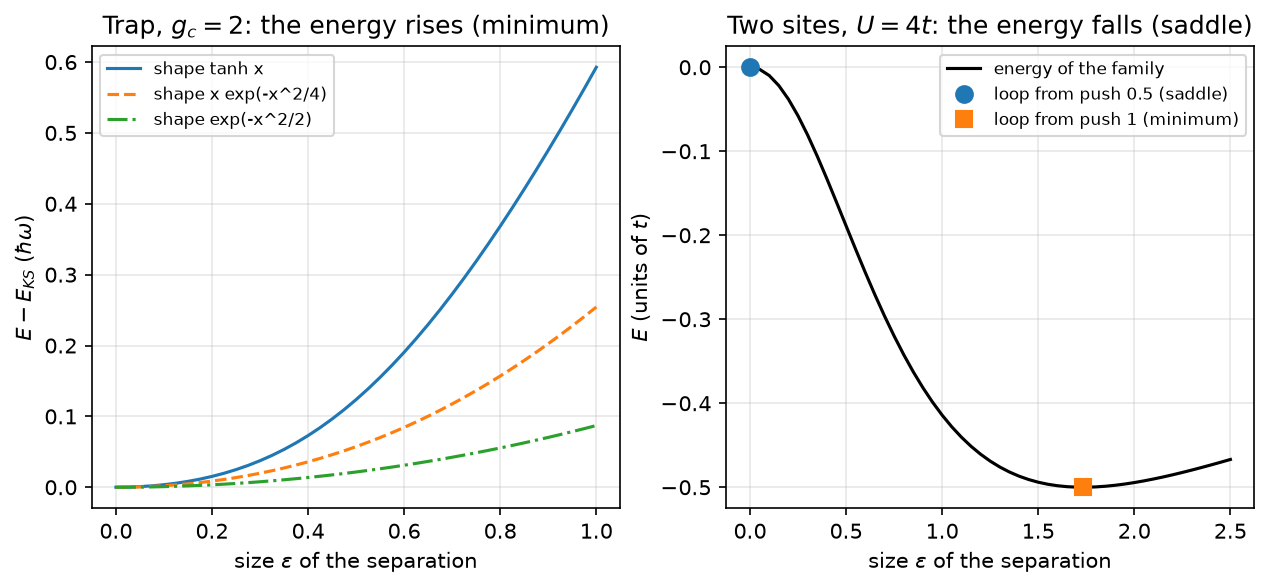

Figure 13a.6 saved as Revision/textbook/figures/13a_6_label_separation.png


In [18]:
shapes = {"tanh x": np.tanh(x), "x exp(-x^2/4)": x * np.exp(-x ** 2 / 4.0),
          "exp(-x^2/2)": np.exp(-x ** 2 / 2.0)}


def separation_rise(shape, size):
    """E of the determinant made from w_scf +- size * shape, minus E_KS."""
    trial = np.concatenate([w_scf + size * shape, w_scf - size * shape])
    return labels_energy(trial, FILLED, FILLED) - E_total


sizes = [0.01, 0.05, 0.2, 0.5, 1.0]
rises = {name: [separation_rise(shape, size) for size in sizes]
         for name, shape in shapes.items()}
for name, values in rises.items():
    say(f"{name:14} E - E_KS: " + " ".join(f"{value:.2e}" for value in values))
check(all(value > 0.0 for values in rises.values() for value in values),
      "every label-separating trial determinant in the trap has a higher energy "
      "than the Kohn-Sham state")
check(all(24.0 < values[1] / values[0] < 26.0 for values in rises.values()),
      "for small separations the energy rises as epsilon^2: in the trap the "
      "equal-label solution is a minimum along these families, not a saddle")
fine_sizes = np.linspace(0.0, 1.0, 41)  # epsilon = 0, 0.025, ..., 1
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
for (name, shape), style in zip(shapes.items(), ("-", "--", "-.")):
    left.plot(fine_sizes, [separation_rise(shape, size) for size in fine_sizes],
              style, label=f"shape {name}")
left.set_xlabel("size $\\epsilon$ of the separation")
left.set_ylabel("$E - E_{KS}$ ($\\hbar\\omega$)")
left.set_title("Trap, $g_c = 2$: the energy rises (minimum)")
left.legend(fontsize=8)
right.plot(site_sizes, site_family, color="black", label="energy of the family")
right.plot([0.0], [site_family[0]], "o", ms=8,
           label="loop from push 0.5 (saddle)")
size_end = 0.5 * (site_ends[1.0][1] - site_ends[1.0][0])  # (w_R - w_L)/2 of up
right.plot([size_end], [sites_energy(site_ends[1.0])], "s", ms=8,
           label="loop from push 1 (minimum)")
right.set_xlabel("size $\\epsilon$ of the separation")
right.set_ylabel("$E$ (units of $t$)")
right.set_title("Two sites, $U = 4t$: the energy falls (saddle)")
right.legend(fontsize=8)
save_figure(fig, "label_separation",
            "The energy test of stability. Left: the trap with eight fermions; "
            "the energy of the determinant made from the label-separating trial "
            "potentials $w_{scf} \\pm \\epsilon\\,s(x)$, minus the Kohn-Sham "
            "energy, for three shapes $s$, against the size $\\epsilon$ (pure "
            "number); vertical axis in units of $\\hbar\\omega$. Every curve starts "
            "flat at 0 and rises: along these families the equal-label solution "
            "is a minimum. Right: two sites with $U = 4t$; the energy of the "
            "determinant made from the potentials $U/2 \\pm \\epsilon\\,(-1, 1)$, "
            "in units of $t$, against $\\epsilon$. It falls from the equal-label "
            "solution (circle, energy 0, where the loop from push 0.5 converged: "
            "a saddle) to the separated minimum $-2t^2/U = -0.5t$ (square, where "
            "the loop from push 1 converged). The converged loop could not tell "
            "the two cases apart; the energy does.")

## 11. The variational principle at work

The Kohn-Sham equations were derived by asking that the energy $E$ be stationary
when the orbitals change (with their normalisation kept): a small change of the
self-consistent orbitals changes $E$ only to second order, and for the ground state
the stationary point is a minimum. The next cell tests this on a one-parameter
family of determinants: for each number $c$ it takes the four lowest orbitals of the
potential $v + c\,n_{scf}$, puts two fermions into each, and evaluates the SAME
energy formula $E = T_s + \int v n\,dx + \tfrac{g_c}{4}\int n^2\,dx$ for them. At
$c = g_c/2 = 1$ the orbitals are exactly the self-consistent ones. The energy must be
smallest there, and larger for every other $c$.

In [19]:
def energy_of_orbitals(phi):
    """E = T_s + int v n dx + (g_c/4) int n^2 dx for 2 fermions in orbitals 0..3."""
    n = density(phi)
    return (kinetic(phi, [2.0] * N_PER_LABEL) + integral(v * n)
            + 0.25 * G_C * integral(n ** 2))


c_values = np.linspace(0.0, 2.0, 41)  # c = 0, 0.05, ..., 2
family_energies = np.array([energy_of_orbitals(orbitals(c * n_scf)[1])
                            for c in c_values])
c_best = c_values[np.argmin(family_energies)]
report("c of the lowest energy in the family", f"{c_best:.2f}")
check(abs(c_best - 0.5 * G_C) < 1e-9,
      "the lowest energy of the family is at c = g_c/2 (the self-consistent one)")
check(np.all(family_energies >= E_total - 1e-10),
      "no member of the family has a lower energy than the Kohn-Sham state")

RESULT c of the lowest energy in the family = 1.00
PASS the lowest energy of the family is at c = g_c/2 (the self-consistent one)
PASS no member of the family has a lower energy than the Kohn-Sham state


The next cell draws the energy of the family against $c$. Near its lowest point the
curve is flat (a parabola): a small error in the orbitals makes only a much smaller
(second-order) error in the energy, a general property of variational methods.

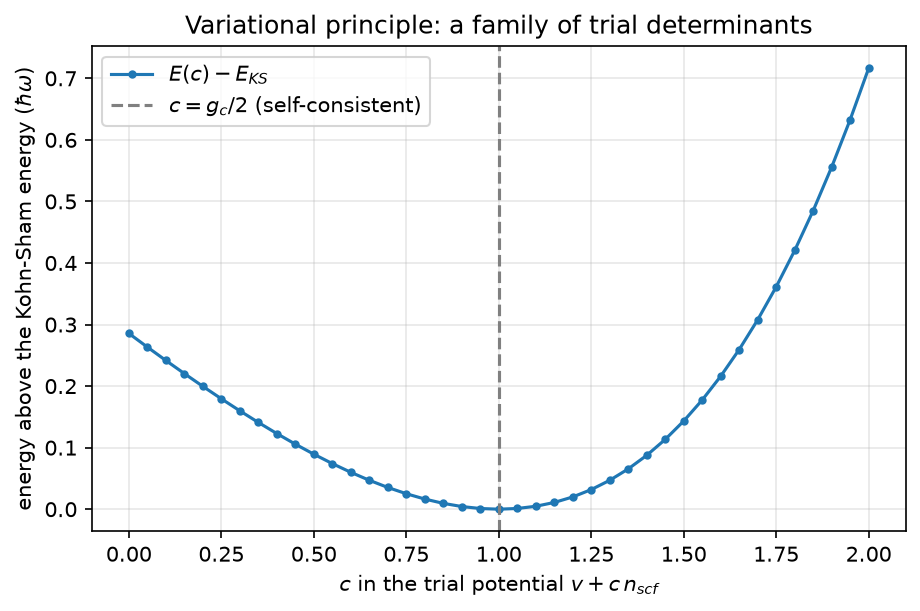

Figure 13a.7 saved as Revision/textbook/figures/13a_7_variational_scan.png


In [20]:
fig, ax = plt.subplots()
ax.plot(c_values, family_energies - E_total, "o-", ms=3,
        label="$E(c) - E_{KS}$")
ax.axvline(0.5 * G_C, color="gray", ls="--", label="$c = g_c/2$ (self-consistent)")
ax.set_xlabel("$c$ in the trial potential $v + c\\,n_{scf}$")
ax.set_ylabel("energy above the Kohn-Sham energy ($\\hbar\\omega$)")
ax.set_title("Variational principle: a family of trial determinants")
ax.legend()
save_figure(fig, "variational_scan",
            "The energy $E(c)$ of the determinant built from the four lowest "
            "orbitals of the trial potential $v + c\\,n_{scf}$, minus the "
            "Kohn-Sham energy, for $c$ from 0 to 2; horizontal axis $c$ (the same "
            "units as $g_c$), vertical axis the energy difference in units of "
            "$\\hbar\\omega$. The curve is never negative and touches zero at the "
            "self-consistent value $c = g_c/2 = 1$ (dashed line), where it is flat: "
            "the variational principle.")

## 12. Three simpler pictures compared

The next cell computes two other densities for comparison. **Hartree only** drops
the exchange term, so the potential is $v + g_c n$: every fermion is also repelled
by its own density (self-interaction). The **Thomas-Fermi** density uses the
uniform-gas kinetic energy at the local density instead of the orbitals. For a
uniform gas on a line with two labels, the states with wave numbers
$|k| < k_F$ are filled, two per state, so $n = 2k_F/\pi$, and the kinetic energy
per unit length is $2\int_{-k_F}^{k_F} \frac{dk}{2\pi}\frac{k^2}{2} =
k_F^3/(3\pi) = \pi^2 n^3/24$. Minimising
$\int [\pi^2 n^3/24 + v n + \tfrac{g_c}{4} n^2]\,dx$ at fixed $N$ (Lagrange
multiplier $\mu$) gives $\pi^2 n^2/8 + v + g_c n/2 = \mu$ where $n > 0$, a
quadratic equation for $n$ at each point; $\mu$ is found by bisection so that the
density holds 8 particles.

In [21]:
def hartree_map(w):
    """One pass of the Hartree approximation: w_out = g_c n (no exchange)."""
    return G_C * density(orbitals(w)[1])


w_hartree, hartree_residuals = anderson(hartree_map, np.zeros(M))
n_hartree = density(orbitals(w_hartree)[1])
n_free = density(free_phi)  # no interaction at all


def thomas_fermi(mu):
    """The Thomas-Fermi density: the positive root of a n^2 + b n = mu - v."""
    a, b = np.pi ** 2 / 8.0, 0.5 * G_C
    room = np.maximum(mu - v, 0.0)  # zero where the trap is higher than mu
    return (-b + np.sqrt(b * b + 4.0 * a * room)) / (2.0 * a)


low, high = 0.0, 50.0  # mu lies between these two numbers
for _ in range(60):  # bisection: halve the interval 60 times
    middle = 0.5 * (low + high)
    if integral(thomas_fermi(middle)) < N_TOTAL:
        low = middle  # too few particles: mu must be larger
    else:
        high = middle
mu_tf = 0.5 * (low + high)
n_tf = thomas_fermi(mu_tf)
report("Thomas-Fermi chemical potential mu", f"{mu_tf:.6f}")
check(abs(integral(n_tf) - N_TOTAL) < 1e-9, "the Thomas-Fermi density holds 8")
check(abs(integral(n_hartree) - N_TOTAL) < 1e-10, "the Hartree density holds 8")
widths = [np.sqrt(integral(x ** 2 * n) / N_TOTAL)
          for n in (n_free, n_ks, n_hartree)]
say("root-mean-square widths: free {:.6f}, Kohn-Sham {:.6f}, Hartree {:.6f}"
    .format(*widths))
check(widths[0] < widths[1] < widths[2],
      "repulsion widens the cloud, and self-interaction (Hartree) widens it more")

RESULT Thomas-Fermi chemical potential mu = 5.110729
PASS the Thomas-Fermi density holds 8
PASS the Hartree density holds 8
root-mean-square widths: free 1.413346, Kohn-Sham 1.542829, Hartree 1.659857
PASS repulsion widens the cloud, and self-interaction (Hartree) widens it more


The next cell draws the four densities together.

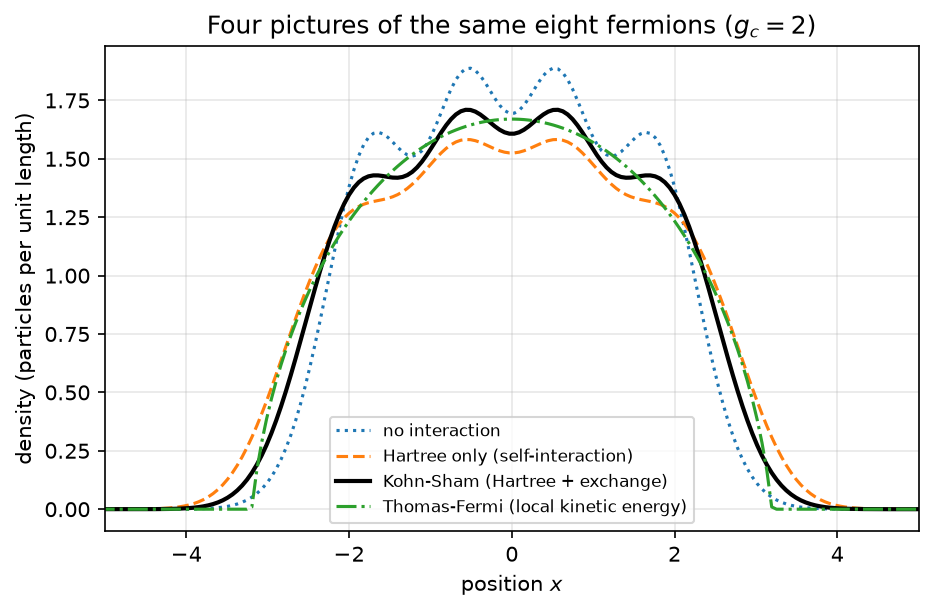

Figure 13a.8 saved as Revision/textbook/figures/13a_8_approximations.png


In [22]:
fig, ax = plt.subplots()
ax.plot(x, n_free, ":", label="no interaction")
ax.plot(x, n_hartree, "--", label="Hartree only (self-interaction)")
ax.plot(x, n_ks, lw=2.0, color="black", label="Kohn-Sham (Hartree + exchange)")
ax.plot(x, n_tf, "-.", label="Thomas-Fermi (local kinetic energy)")
ax.set_xlim(-5.0, 5.0)
ax.set_xlabel("position $x$")
ax.set_ylabel("density (particles per unit length)")
ax.set_title("Four pictures of the same eight fermions ($g_c = 2$)")
ax.legend(fontsize=8)
save_figure(fig, "approximations",
            "Four densities of the eight fermions in the trap: without "
            "interaction (dotted), the Hartree approximation that keeps the "
            "self-interaction (dashed), Kohn-Sham with Hartree and exact exchange "
            "(thick black) and Thomas-Fermi with the uniform-gas kinetic energy "
            "(dash-dotted); horizontal axis the position $x$, vertical axis "
            "particles per unit length. The repulsion spreads the cloud; Hartree "
            "overdoes it; Thomas-Fermi follows the Kohn-Sham density on average but "
            "misses its four shell bumps.")

## 13. Switching the interaction on

The next cell solves the model for nine strengths $g_c = 0, 0.25, \dots, 2$, each
time starting from the solution of the previous strength, and records the energies.
It also checks the **Hellmann-Feynman theorem**: because the energy is stationary in
the orbitals, its derivative with respect to $g_c$ is only the explicit one,
$dE/dg_c = \tfrac14\int n^2\,dx$; the check compares this with the difference
quotient $(E(g_c + \delta) - E(g_c - \delta))/(2\delta)$ at $g_c = 2$,
$\delta = 10^{-3}$.

In [23]:
def solve_at(strength, start):
    """The self-consistent w and the three energies (T_s, int v n dx, E_H + E_x)
    at the coupling strength, starting the loop from the potential start."""

    def strength_map(w):  # the Kohn-Sham map with this strength instead of G_C
        return 0.5 * strength * density(orbitals(w)[1])

    w, _ = anderson(strength_map, start)
    phi = orbitals(w)[1]
    n = density(phi)
    parts = (kinetic(phi, [2.0] * N_PER_LABEL), integral(v * n),
             0.25 * strength * integral(n ** 2))
    return w, parts


strengths = np.linspace(0.0, 2.0, 9)  # g_c = 0, 0.25, ..., 2
scan, w_start = [], np.zeros(M)
for strength in strengths:
    w_start, parts = solve_at(strength, w_start)  # start from the last solution
    scan.append(parts)
scan = np.array(scan)  # one row per strength; columns: T_s, int v n, E_H + E_x
say(f"E at g_c = 0: {scan[0].sum():.6f}; at g_c = 2: {scan[-1].sum():.6f}")
check(abs(scan[-1].sum() - E_total) < 1e-9, "the scan ends at the same E as above")
delta = 1e-3
E_plus = sum(solve_at(2.0 + delta, w_scf)[1])  # E at g_c = 2.001
E_minus = sum(solve_at(2.0 - delta, w_scf)[1])  # E at g_c = 1.999
slope = (E_plus - E_minus) / (2.0 * delta)
report("dE/dg_c at g_c = 2 (difference quotient)", f"{slope:.6f}")
report("(1/4) int n^2 dx at g_c = 2 (Hellmann-Feynman)",
       f"{0.25 * integral(n_ks ** 2):.6f}")
check(abs(slope - 0.25 * integral(n_ks ** 2)) < 1e-6,
      "Hellmann-Feynman: dE/dg_c = (1/4) int n^2 dx")

E at g_c = 0: 15.990192; at g_c = 2: 21.851498
PASS the scan ends at the same E as above
RESULT dE/dg_c at g_c = 2 (difference quotient) = 2.801961
RESULT (1/4) int n^2 dx at g_c = 2 (Hellmann-Feynman) = 2.801961
PASS Hellmann-Feynman: dE/dg_c = (1/4) int n^2 dx


The next cell draws the energies of the scan. As $g_c$ grows, the interaction energy
$E_H + E_x$ rises; the cloud spreads, which lowers the kinetic energy (wider orbitals
curve less) and raises the trap energy (the particles sit higher on the parabola).

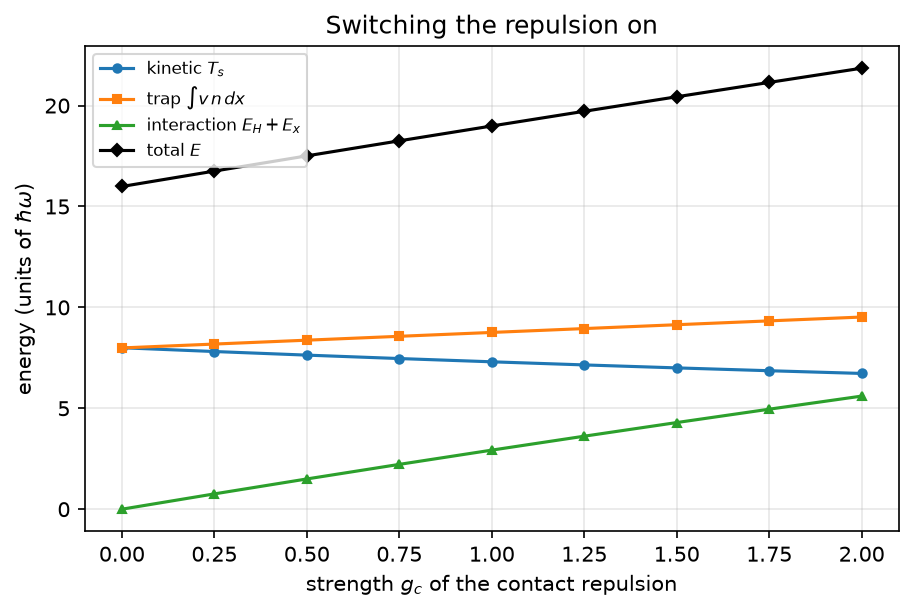

Figure 13a.9 saved as Revision/textbook/figures/13a_9_coupling_scan.png
PASS at g_c = 0: E = 16 and T_s equals the trap energy (virial theorem)


In [24]:
fig, ax = plt.subplots()
ax.plot(strengths, scan[:, 0], "o-", ms=4, label="kinetic $T_s$")
ax.plot(strengths, scan[:, 1], "s-", ms=4, label="trap $\\int v\\,n\\,dx$")
ax.plot(strengths, scan[:, 2], "^-", ms=4, label="interaction $E_H + E_x$")
ax.plot(strengths, scan.sum(axis=1), "D-", ms=4, color="black",
        label="total $E$")
ax.set_xlabel("strength $g_c$ of the contact repulsion")
ax.set_ylabel("energy (units of $\\hbar\\omega$)")
ax.set_title("Switching the repulsion on")
ax.legend(fontsize=8)
save_figure(fig, "coupling_scan",
            "The parts of the Kohn-Sham energy of the eight fermions as the "
            "strength $g_c$ of the contact repulsion grows from 0 to 2: kinetic "
            "energy $T_s$, trap energy, interaction energy $E_H + E_x$ and the "
            "total (black); horizontal axis $g_c$, vertical axis the energy in "
            "units of $\\hbar\\omega$. At $g_c = 0$ the total is "
            "$2(1/2 + 3/2 + 5/2 + 7/2) = 16$ (15.99 on the grid, whose levels lie "
            "slightly below $n + 1/2$) and kinetic and trap energy are equal "
            "(virial theorem); the repulsion spreads the cloud, so the trap energy "
            "rises and the kinetic energy falls.")
check(abs(scan[0].sum() - 16.0) < 0.05 and abs(scan[0, 0] - scan[0, 1]) < 0.05,
      "at g_c = 0: E = 16 and T_s equals the trap energy (virial theorem)")

## 14. The first excited state: Kohn-Sham gap and Delta-SCF

The **Kohn-Sham gap** is the difference of the LUMO and HOMO levels of the ground
state. The **Delta-SCF** excitation energy moves one up fermion from orbital 3 (HOMO)
to orbital 4 (LUMO) and solves the loop again with these occupations; it is the
difference of the two total energies. **Janak's theorem** says that the derivative
of the self-consistent energy with respect to an occupation is the level of that
orbital. Moving a fraction $\tau$ of the fermion (occupations $1 - \tau$ in orbital
3 and $\tau$ in orbital 4 of label up) therefore gives
$dE/d\tau = \epsilon_4(\tau) - \epsilon_3(\tau)$, and

$$\Delta_{SCF} = E(1) - E(0) = \int_0^1 [\epsilon_4(\tau) - \epsilon_3(\tau)]\,d\tau .$$

The next cell solves the two-label loop for nine values $\tau = 0, 1/8, \dots, 1$
and integrates the level difference with Simpson's rule (exact for cubic
polynomials, very accurate for smooth curves).

In [25]:
taus = np.linspace(0.0, 1.0, 9)
gaps, energies, w_pair = [], [], np.concatenate([w_scf, w_scf])
for tau in taus:
    up = [1.0, 1.0, 1.0, 1.0 - tau, tau]  # orbitals 0..4 of label up
    w_pair, _ = anderson(lambda q: labels_map(q, up, FILLED), w_pair)
    up_levels = label_densities(w_pair, up, FILLED)[2]
    gaps.append(up_levels[4] - up_levels[3])  # eps_4(tau) - eps_3(tau)
    energies.append(labels_energy(w_pair, up, FILLED))
gaps, energies = np.array(gaps), np.array(energies)
n_excited = sum(label_densities(w_pair, up, FILLED)[:2])  # tau = 1: n_up + n_down
step = taus[1] - taus[0]
simpson = step / 3.0 * (gaps[0] + gaps[-1] + 4.0 * gaps[1:-1:2].sum()
                        + 2.0 * gaps[2:-1:2].sum())
delta_scf = energies[-1] - energies[0]
report("Kohn-Sham gap (LUMO - HOMO)", f"{gaps[0]:.6f}")
report("Delta-SCF excitation energy E(1) - E(0)", f"{delta_scf:.6f}")
report("Janak integral of eps_4 - eps_3 (Simpson)", f"{simpson:.6f}")
report("transition state eps_4 - eps_3 at tau = 1/2", f"{gaps[4]:.6f}")
check(abs(energies[0] - E_total) < 1e-9, "tau = 0 is the ground state")
check(abs(gaps[0] - (ks_levels[4] - ks_levels[3])) < 1e-9,
      "at tau = 0 the level difference is the Kohn-Sham gap")
check(abs(simpson - delta_scf) < 1e-6,
      "Janak's theorem: the integral of eps_4 - eps_3 equals Delta-SCF")
check(delta_scf < gaps[0], "orbital relaxation lowers the excitation energy here")

RESULT Kohn-Sham gap (LUMO - HOMO) = 0.772662
RESULT Delta-SCF excitation energy E(1) - E(0) = 0.714594
RESULT Janak integral of eps_4 - eps_3 (Simpson) = 0.714594
RESULT transition state eps_4 - eps_3 at tau = 1/2 = 0.712784
PASS tau = 0 is the ground state
PASS at tau = 0 the level difference is the Kohn-Sham gap
PASS Janak's theorem: the integral of eps_4 - eps_3 equals Delta-SCF
PASS orbital relaxation lowers the excitation energy here


The next cell draws the level difference against $\tau$ (its area is the Delta-SCF
energy) and compares the ground-state density with the density of the excited state.

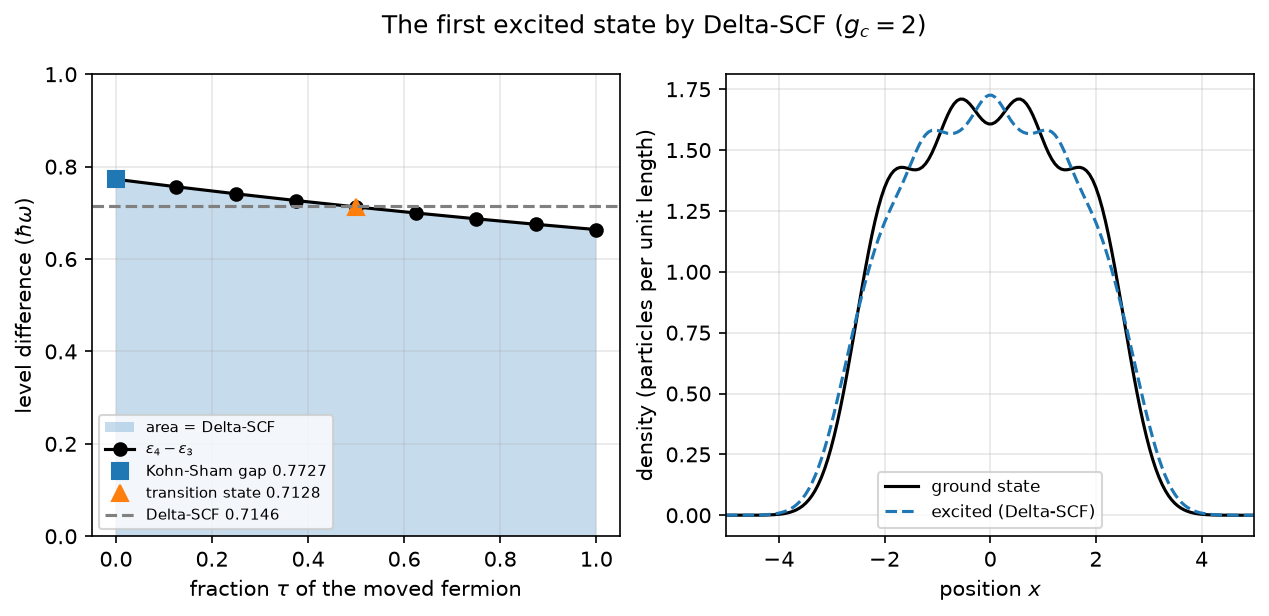

Figure 13a.10 saved as Revision/textbook/figures/13a_10_delta_scf.png


In [26]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
left.fill_between(taus, 0.0, gaps, alpha=0.25, label="area = Delta-SCF")
left.plot(taus, gaps, "o-", color="black", label="$\\epsilon_4 - \\epsilon_3$")
left.plot([0.0], [gaps[0]], "s", ms=8, label=f"Kohn-Sham gap {gaps[0]:.4f}")
left.plot([0.5], [gaps[4]], "^", ms=8, label=f"transition state {gaps[4]:.4f}")
left.axhline(delta_scf, color="gray", ls="--", label=f"Delta-SCF {delta_scf:.4f}")
left.set_ylim(0.0, 1.0)
left.set_xlabel("fraction $\\tau$ of the moved fermion")
left.set_ylabel("level difference ($\\hbar\\omega$)")
left.legend(fontsize=7, loc="lower left")
right.plot(x, n_ks, color="black", label="ground state")
right.plot(x, n_excited, "--", label="excited (Delta-SCF)")
right.set_xlim(-5.0, 5.0)
right.set_xlabel("position $x$")
right.set_ylabel("density (particles per unit length)")
right.legend(fontsize=8)
fig.suptitle("The first excited state by Delta-SCF ($g_c = 2$)")
save_figure(fig, "delta_scf",
            "Left: the level difference $\\epsilon_4(\\tau) - \\epsilon_3(\\tau)$ of "
            "label up when a fraction $\\tau$ of one fermion is moved from orbital 3 "
            "to orbital 4 (horizontal axis $\\tau$, vertical axis energy in units "
            "of $\\hbar\\omega$); its value at $\\tau = 0$ is the Kohn-Sham gap, at "
            "$\\tau = 1/2$ the transition-state estimate, and the shaded area is "
            "the Delta-SCF excitation energy (dashed line), by Janak's theorem. "
            "Right: the ground-state density and the density of the excited state "
            "(horizontal axis $x$); the moved fermion sits in orbital 4, which has "
            "four zeros, so the shell bumps change and a little more density "
            "reaches the outer flanks.")

## 15. The last check

The last cell checks that all ten figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [27]:
figure_names = ["trap_orbitals", "scf_convergence", "first_iterations",
                "ks_potentials", "density_orbitals", "label_separation",
                "variational_scan", "approximations", "coupling_scan",
                "delta_scf"]
missing = [name for k, name in enumerate(figure_names, 1)
           if not output_file(f"{FIGURE_FOLDER}/13a_{k}_{name}.png").is_file()]
check(missing == [], "all ten figure files exist")
check(output_file(f"{FIGURE_FOLDER}/13a_10_delta_scf.png").is_file(),
      "the figure file 13a_10_delta_scf.png exists")
all_checks_passed()

PASS all ten figure files exist
PASS the figure file 13a_10_delta_scf.png exists
ALL 36 CHECKS PASSED (notebook 13a)


## 16. What this notebook showed

- The Kohn-Sham equations of eight fermions with a contact repulsion reduce to
  one-particle equations in the potential $v_s = v + g_c n/2$: the Hartree push
  $g_c n$ minus the exchange $g_c n/2$, which removes the repulsion between fermions
  with the same label.
- The self-consistency loop converges by plain iteration, by linear mixing and by
  Anderson mixing to the same solution; the speed depends on the mixing parameter,
  and plain iteration overshoots (the density swings in and out). Anderson mixing
  with the settings of the Revision solver (depth 6, $\beta = 0.4$, tolerance
  $10^{-11}$) is the fastest without any tuning.
- The direct energy and the double-counting formula agree; $E_x = -E_H/2$ for two
  equally occupied labels; the mean-field potential $g_c n/2$ is the functional
  derivative of $E_H + E_x$. A converged two-label loop cannot tell a minimum
  from a saddle (on two sites with $U = 4t$ it converges to a saddle); the energy
  test shows that at $g_c = 2$ the equal-label solution in the trap is a minimum
  along three families of label-separating changes.
- Among a family of trial determinants the self-consistent one has the lowest
  energy, and the energy is flat there (variational principle); the derivative of
  the energy with respect to $g_c$ is $\tfrac14\int n^2\,dx$ (Hellmann-Feynman).
- Hartree alone overestimates the spreading (self-interaction); Thomas-Fermi gets
  the average shape but not the shell bumps, because it does not use orbitals.
- The Delta-SCF excitation energy is below the Kohn-Sham gap here, and it equals the
  integral of the level difference over the moved fraction (Janak's theorem).
- What was left out: the correlation energy. All numbers are those of the
  exchange-only (Hartree-Fock) approximation of this teaching model.